In [1]:
import pandas as pd

# Load tables (replace 'file.csv' with actual file paths)
drug = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\DDI\drug_table_final.xlsx")   # Patient demographic data
demo = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\DDI\demo_table.xlsx")   # Drugs prescribed
hist = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\DDI/hist_table.xlsx")   # Adverse events
reac = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\DDI/react_table.xlsx")   # Medical history

# Display first few rows
print(drug.head())
print(reac.head())
print(drug.columns)  # Check column names in drug
print(reac.columns)  # Check column names in reac

  Identification number  Number of reports  Drug serial number  \
0           AB-04000003                  1                   1   
1           AB-04000005                  2                   1   
2           AB-04000005                  2                   2   
3           AB-04000005                  2                   3   
4           AB-04000005                  2                   4   

  Pharmaceutical involvement                  Medicines (generic name)  \
0             Suspected drug  Otologic agents (over-the-counter drugs)   
1             Suspected drug                                Olanzapine   
2    Concomitant medications                               Risperidone   
3    Concomitant medications                   Biperiden hydrochloride   
4    Concomitant medications              Chlorpromazine hydrochloride   

  Pharmaceuticals (brand name) route  Start date of administration  \
0         Pabron Nasal Spray S  nose                    20040104.0   
1                 

In [2]:
# Merge DRUG and REAC tables to link drugs with adverse events
df = pd.merge(drug, reac, on="Identification number", how="inner", suffixes=("_df", "_hist"))

# Merge with DEMO and HIST tables (optional but useful)
df = pd.merge(df, demo, on="Identification number", how="left")
df = pd.merge(df, hist, on="Identification number", how="left")

# Display merged data
print(df.head())
print(df.columns) 

  Identification number  Number of reports_df  Drug serial number  \
0           AB-04000003                     1                   1   
1           AB-04000005                     2                   1   
2           AB-04000005                     2                   2   
3           AB-04000005                     2                   3   
4           AB-04000005                     2                   4   

  Pharmaceutical involvement                  Medicines (generic name)  \
0             Suspected drug  Otologic agents (over-the-counter drugs)   
1             Suspected drug                                Olanzapine   
2    Concomitant medications                               Risperidone   
3    Concomitant medications                   Biperiden hydrochloride   
4    Concomitant medications              Chlorpromazine hydrochloride   

  Pharmaceuticals (brand name) route  Start date of administration  \
0         Pabron Nasal Spray S  nose                    20040104.0   


In [3]:
# 
print(df.columns) 
df_subset = df[['Identification number', 'Medicines (generic name)', 'Adverse events']]  # Only keep drug names & adverse events
print(df_subset.columns)

print(df_subset.head(10))


Index(['Identification number', 'Number of reports_df', 'Drug serial number',
       'Pharmaceutical involvement', 'Medicines (generic name)',
       'Pharmaceuticals (brand name)', 'route', 'Start date of administration',
       'End date of administration', 'Dosage', 'Dosage Unit',
       'Number of divided doses', 'Reasons for use',
       'Pharmaceutical Treatment', 'Relapse after re-administration',
       'Risk classification, etc.', 'Number of reports_hist',
       'Adverse Event Serial Number', 'Adverse events', 'Outcome',
       'Date of onset of adverse event', 'Number of reports_x', 'sex', 'age',
       'body weight', 'height', 'Reporting Year/Quarter', 'situation',
       'Report Type', 'Qualifications of the reporter', 'E2B',
       'Number of reports_y', 'Primary disease serial number',
       'Primary disease, etc.'],
      dtype='object')
Index(['Identification number', 'Medicines (generic name)', 'Adverse events'], dtype='object')
  Identification number               

In [4]:
# Group drugs and reactions by CASE_ID
#transactions = df_subset.groupby('Identification number').agg(lambda x: list(x)).reset_index()
#print(transactions.head(10))

transactions = df_subset.groupby('Identification number').agg(lambda x: set(x)).reset_index()
print(transactions.head(20))


# Ensure each transaction contains separate drugs & adverse events
transactions_list = [
    (list(set(row['Medicines (generic name)'])), list(set(row['Adverse events'])))
    for _, row in transactions.iterrows()
]

# Ensure each transaction is stored as a single string, not split into characters
#transactions_list = [
    #(list(set(map(str, row['Medicines (generic name)']))), 
     #list(set(map(str, row['Adverse events']))))
    #for _, row in transactions.iterrows()
#]

# Print first few transactions to verify correct format
print(transactions_list[1:2])


# Print example transactions
print(transactions_list[7:10])  # First 5 transactions

#import pandas as pd
#from mlxtend.preprocessing import TransactionEncoder
#from mlxtend.frequent_patterns import apriori, association_rules

# **Step 1: Load the Merged Dataset**
#df = pd.read_csv("merged_dataset.csv")  # Ensure your dataset is merged properly

# **Step 2: Extract Drugs and Adverse Events Separately**
#df_subset = df[['Identification number', 'Medicines (generic name)', 'Adverse events']]

# **Fix 1: Use .loc to modify the DataFrame safely**
# **Fix 1: Use .loc to modify the DataFrame safely**
#df_subset.loc[:, 'Medicines (generic name)'] = df_subset['Medicines (generic name)'].apply(lambda x: x.split(', ') if isinstance(x, str) else x)
#df_subset.loc[:, 'Adverse events'] = df_subset['Adverse events'].apply(lambda x: x.split(', ') if isinstance(x, str) else x)

# Get unique drugs and adverse events
#unique_drugs = df_subset['Medicines (generic name)'].explode().unique()
#unique_adverse_events = df_subset['Adverse events'].explode().unique()

# **Step 3: Prepare Transactions (Only Drugs)**
#drug_transactions = df_subset.groupby('Identification number')['Medicines (generic name)'].apply(list).tolist()

# **Fix 2: Flatten Nested Lists in drug_transactions**
#drug_transactions = [sum(drugs, []) if isinstance(drugs[0], list) else drugs for drugs in drug_transactions]

# **Step 4: Encode Drug Transactions**
#te = TransactionEncoder()
#te_ary = te.fit(drug_transactions).transform(drug_transactions)
#df_drug_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# **Step 5: Apply Apriori Algorithm on Drugs Only**
#min_support_threshold = 0.003  # Adjust support as needed
#frequent_itemsets = apriori(df_drug_encoded, min_support=min_support_threshold, use_colnames=True)

# **Step 6: Generate Association Rules**
#rules = association_rules(frequent_itemsets, metric="lift", min_threshold=0.7)

# **Step 7: Filter Rules**
#valid_rules = rules[
    #(rules['antecedents'].apply(lambda x: all(item in unique_drugs for item in x))) &  # Only drugs in antecedents
    #(rules['consequents'].apply(lambda x: all(item in unique_adverse_events for item in x)))  # Only adverse events in consequents
#]

# **Step 8: Convert frozensets to Readable Strings**
#valid_rules.loc[:, 'antecedents'] = valid_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
#valid_rules.loc[:, 'consequents'] = valid_rules['consequents'].apply(lambda x: ', '.join(list(x)))

# **Step 9: Display & Save Results**
#print(valid_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
#valid_rules.to_csv("filtered_apriori_results.csv", index=False)  # Save results for Weka

   Identification number                           Medicines (generic name)  \
0            AB-04000003         {Otologic agents (over-the-counter drugs)}   
1            AB-04000005  {Biperiden hydrochloride, Quazepam, Chlorproma...   
2            AB-04000006  {Biperiden hydrochloride, Olanzapine, Quetiapi...   
3            AB-04000008  {Atenolol, Prednisolone, Pravastatin Sodium, M...   
4            AB-04000010  {Infliximab (genetical recombination), Mesalaz...   
5            AB-04000011  {Diazepam, Alfacalcidol, Levothyroxine Sodium ...   
6            AB-04000012  {Ecabet sodium hydrate, Allopurinol, Candesart...   
7            AB-04000013  {Dorzolamide Hydrochloride, Cyanocobalamin, Be...   
8            AB-04000014  {Sulfasalazine, Azulenesulfonic acid sodium hy...   
9            AB-04000015  {Sodium Azulenesulfonate Hydrate, Azithromycin...   
10           AB-04000016  {Paclitaxel, Cisplatin, Sodium heparin, Ioprom...   
11           AB-04000017  {Tipepidine hibenzate, Cyp

In [5]:
from mlxtend.preprocessing import TransactionEncoder

# Convert transactions into a flat list of drugs + adverse events
flat_transactions = [drugs + events for drugs, events in transactions_list]
#flat_transactions = [drugs , events in transactions_list]


print(flat_transactions[:4])
# Apply TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(flat_transactions).transform(flat_transactions)

# Convert to DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
print(df_encoded.head())  # Check structured data


[['Otologic agents (over-the-counter drugs)', 'Scintillating scotoma'], ['Zopiclone', 'Biperiden hydrochloride', 'Quazepam', 'Chlorpromazine hydrochloride', 'Risperidone', 'Olanzapine', 'Psychotropic drugs', 'Suicide attempt'], ['Biperiden hydrochloride', 'Risperidone', 'Olanzapine', 'Quetiapine fumarate', 'Perospirone hydrochloride hydrate', 'Sodium valproate', 'Tardive dyskinesia', 'Dystonia'], ['Atenolol', 'Prednisolone', 'Pravastatin Sodium', 'Morphine sulfate hydrate', 'Fentanyl', 'Gemcitabine hydrochloride', 'Ranitidine Hydrochloride', 'Rilmazafone hydrochloride hydrate', 'Tamsulosin hydrochloride', 'Morphine hydrochloride hydrate', 'Increased blood creatinine', 'Decreased hemoglobin', 'Increased blood urea']]
    TSU-68  1-(4-methylphenyl)ethyl nicotinate, 1-naphthylacetic acid  \
0    False                                              False           
1    False                                              False           
2    False                                             

In [6]:
from mlxtend.frequent_patterns import apriori, association_rules

# Apply Apriori with appropriate support
frequent_itemsets = apriori(df_encoded, min_support=0.003, use_colnames=True)

# Generate Association Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
#rules = rules[rules['confidence'] >= 0.7]  # Apply confidence filtering

# **Filter only rules where antecedents contain Drugs & consequents contain Adverse Events**
#valid_rules = rules[
    #rules['antecedents'].apply(lambda x: any(item in df_subset['Medicines (generic name)'].unique() for item in x)) &
    #rules['consequents'].apply(lambda x: any(item in df_subset['Adverse events'].unique() for item in x))
#]

valid_rules = rules[
    rules['antecedents'].apply(lambda x: any(item in df_subset['Medicines (generic name)'].unique() for item in x))
    ]

# Convert frozensets to readable strings
valid_rules.loc[:, 'antecedents'] = valid_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
#valid_rules.loc[:, 'consequents'] = valid_rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Display top valid rules
#print(valid_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
print(valid_rules[['antecedents',  'support', 'confidence', 'lift']])


                                            antecedents   support  confidence  \
0                                         Acetaminophen  0.003533    0.207031   
1                                 Oseltamivir phosphate  0.003533    0.268354   
2                  Infliximab (genetical recombination)  0.006467    0.290419   
3                                      Adrenal hormones  0.006467    0.646667   
4                                      Adrenal hormones  0.006633    0.663333   
...                                                 ...       ...         ...   
1242                            pneumonia, Methotrexate  0.003567    0.758865   
1243  Infliximab (genetical recombination), Methotre...  0.003567    0.193841   
1244                                       Prednisolone  0.003567    0.039194   
1246               Infliximab (genetical recombination)  0.003567    0.160180   
1247                                       Methotrexate  0.003567    0.077201   

           lift  
0     15.

In [7]:
from mlxtend.frequent_patterns import apriori, association_rules

# Calculate minimum support threshold dynamically
min_support_threshold = 20 / len(transactions_list)  # Ensuring nAB1 ≥ 3

# Apply Apriori with calculated min_support
frequent_itemsets = apriori(df_encoded, min_support=min_support_threshold, use_colnames=True)
 # Generate Association Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=0.7)

# Convert support to count (nAB1) and filter
rules['nAB1'] = rules['support'] * len(transactions_list)  # Convert support to actual count
rules = rules[rules['nAB1'] >= 20]  # Keep only rules where nAB1 ≥ 3

# Convert frozensets to readable format
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
#rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Display results
#print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'nAB1']])
print(rules[['antecedents', 'support', 'confidence', 'lift', 'nAB1']])


MemoryError: Unable to allocate 40.3 GiB for an array with shape (721801, 2, 30000) and data type bool

In [8]:
from mlxtend.frequent_patterns import apriori, association_rules


#frequent_itemsets = apriori(df_encoded, min_support=min_support_threshold, use_colnames=True, low_memory=True)


min_support_threshold = max(0.01, 3 / len(transactions_list))  # Ensuring a reasonable min_support

frequent_itemsets = apriori(df_encoded, min_support=min_support_threshold, use_colnames=True, low_memory=True)


#from mlxtend.frequent_patterns import fpgrowth

#frequent_itemsets = fpgrowth(df_encoded, min_support=min_support_threshold, use_colnames=True)


# Filter out infrequent items
item_counts = df_encoded.sum(axis=0)  # Count occurrences of each item
df_filtered = df_encoded.loc[:, item_counts >= 5]  # Keep items appearing at least 5 times

# Run Apriori on the filtered dataset
frequent_itemsets = apriori(df_filtered, min_support=min_support_threshold, use_colnames=True, low_memory=True)


# Generate Association Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=0.7)

# Convert support to count (nAB1) and filter
rules['nAB1'] = rules['support'] * len(transactions_list)  # Convert support to actual count
rules = rules[rules['nAB1'] >= 3]  # Keep only rules where nAB1 ≥ 3

# Convert frozensets to readable format
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Display results
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'nAB1']])



                                          antecedents  \
0                                        Prednisolone   
1                                        Alfacalcidol   
2                                         Allopurinol   
3                                          Furosemide   
4                                 Vincristine sulfate   
5                            Cyclophosphamide hydrate   
6                                        Prednisolone   
7                                   Diclofenac sodium   
8                                          Famotidine   
9                                          Furosemide   
10                                         Famotidine   
11                          Loxoprofen sodium hydrate   
12                                    Magnesium oxide   
13                                         Famotidine   
14                                       Prednisolone   
15                                         Famotidine   
16                             

In [9]:
# Filter rules where antecedents contain more than 2 drugs
filtered_rules = rules[rules['antecedents'].apply(lambda x: len(x) > 2)]

# Convert frozensets to readable format
filtered_rules.loc[:, 'antecedents'] = filtered_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
filtered_rules.loc[:, 'consequents'] = filtered_rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Display results
print(filtered_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


                                          antecedents  \
0                  P, r, e, d, n, i, s, o, l, o, n, e   
1                  A, l, f, a, c, a, l, c, i, d, o, l   
2                     A, l, l, o, p, u, r, i, n, o, l   
3                        F, u, r, o, s, e, m, i, d, e   
4   V, i, n, c, r, i, s, t, i, n, e,  , s, u, l, f...   
5   C, y, c, l, o, p, h, o, s, p, h, a, m, i, d, e...   
6                  P, r, e, d, n, i, s, o, l, o, n, e   
7   D, i, c, l, o, f, e, n, a, c,  , s, o, d, i, u, m   
8                        F, a, m, o, t, i, d, i, n, e   
9                        F, u, r, o, s, e, m, i, d, e   
10                       F, a, m, o, t, i, d, i, n, e   
11  L, o, x, o, p, r, o, f, e, n,  , s, o, d, i, u...   
12        M, a, g, n, e, s, i, u, m,  , o, x, i, d, e   
13                       F, a, m, o, t, i, d, i, n, e   
14                 P, r, e, d, n, i, s, o, l, o, n, e   
15                       F, a, m, o, t, i, d, i, n, e   
16                          T, 

In [10]:
# Keep only rules with High Lift & High Confidence (high-risk interactions)
high_risk_rules = valid_rules[(valid_rules['lift'] > 1.5) & (valid_rules['confidence'] > 0.7)]

print("🚨 High-Risk Drug Combinations 🚨")
print(high_risk_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Save high-risk interactions
high_risk_rules.to_csv("high_risk_drug_interactions.csv", index=False)

🚨 High-Risk Drug Combinations 🚨
                                            antecedents  \
146               Basiliximab (genetical recombination)   
172                                Calcium Levofolinate   
177                                         Oxaliplatin   
219                           Doxorubicin hydrochloride   
229                                 Vincristine sulfate   
...                                                 ...   
1234  Prednisolone, pneumonia, Infliximab (genetical...   
1235              Prednisolone, pneumonia, Methotrexate   
1237  pneumonia, Infliximab (genetical recombination...   
1241    pneumonia, Infliximab (genetical recombination)   
1242                            pneumonia, Methotrexate   

                                            consequents   support  confidence  \
146                             (Mycophenolate mofetil)  0.003633    0.893443   
172                                      (Fluorouracil)  0.007333    0.995475   
177             

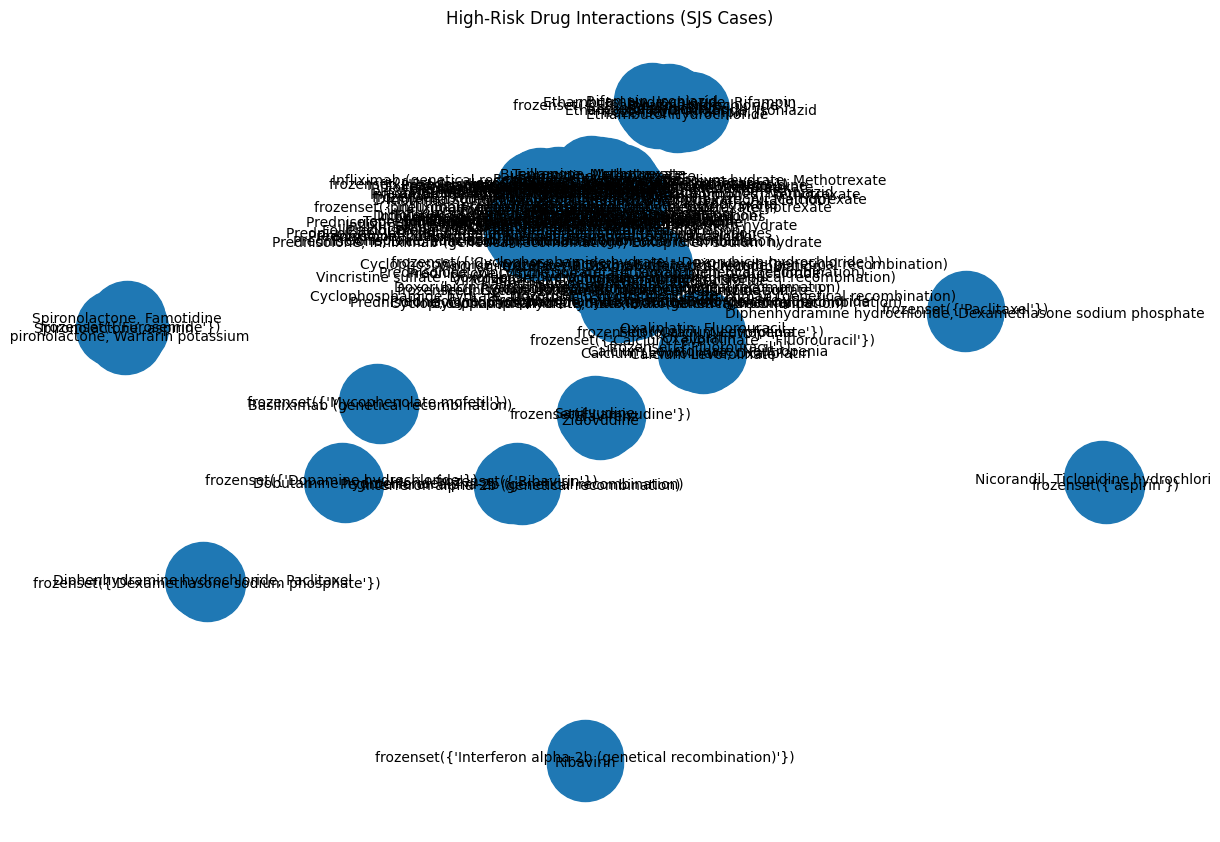

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Add edges for high-risk drug interactions
for _, row in high_risk_rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['lift'])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, font_size=10, edge_color='red')
plt.title("High-Risk Drug Interactions (SJS Cases)")
plt.show()
